# Act1 - Tabular Q

- Pedro Mauri Mtz - A01029143

Tabular Q implementation in a simple MiniGrid environment.

Goal: Get to the target (Red square)

## Imports

In [1]:
from minigrid.core.grid import Grid
from minigrid.core.mission import MissionSpace
from minigrid.core.world_object import Goal, Key, Wall, Lava, Floor
from minigrid.manual_control import ManualControl
from minigrid.minigrid_env import MiniGridEnv

from minigrid.core.actions import Actions

import matplotlib.pyplot as plt
import numpy as np
import random

## Environment

In [2]:
class SimpleEnv(MiniGridEnv):
    
    def __init__(
        self,
        size = 19,
        max_steps: int | None = None,
        **kwargs,
    ):
    
        self.size = size
        self.key_positions = []
        self.lava_positions = []

        self.start_agent_pos = (1, 1)
        
        mission_space = MissionSpace(mission_func = self._gen_mission)
        
        if max_steps is None:
            max_steps = 4 * size ** 2
        
        super().__init__(
            mission_space = mission_space,
            grid_size = size,
            see_through_walls = True,
            max_steps = max_steps,
            **kwargs,
        )

    @staticmethod
    def _gen_mission():
        return "Reach the goal - Tabular Q-Learning"

    def _gen_grid(self, width, height):

        self.grid = Grid(width, height)
        self.grid.wall_rect(0, 0, width, height)
        
        # Place walls in straight lines
        # Vertical walls
        # for y in range(1, height - 1):
        #     self.put_obj(Wall(), width // 2, y)
        
        # # Horizontal walls
        # for x in range(1, width - 1):
        #     self.put_obj(Wall(), x, height // 2)
        
        # # Create openings in the walls
        # openings = [(width // 2, 5), (width // 2, 15), (5, height // 2), (15, height // 2)]
        
        # for x, y in openings:
        #     self.grid.set(x, y, None)

        # Place a goal square in the bottom-right corner
        self.goal_pos = (width - 2, height - 2)
        self.put_obj(Goal(), *self.goal_pos)
        
        self._place_agent()
        
        self.mission = "Reach the goal - Tabular Q-Learning"

    def _place_agent(self):
        # print("Executing place agent")
        # self.agent_pos = (5, 1)
        # self.agent_dir = 0
        # return

        while True:
            # print("Placing agent")
            x = random.randint(1, self.size - 2)
            y = random.randint(1, self.size - 2)
            
            pos = (x, y)
            
            # Filter to only spawn in the bottom right quadrant
            # if (x < self.size // 2 + 1 or y < self.size // 2 + 1):
            #    continue
            
            # print(pos)
            
            # Check if the position is empty (not wall, lava, floor, or goal)
            if (self.grid.get(*pos) is None and pos != self.goal_pos):
                self.agent_pos = pos
                self.agent_dir = random.randint(0, 3) # Random direction
                break

    def reset(self, **kwargs):
        # print("Resetting")
        # self.stepped_floors = set()
        out = super().reset(**kwargs)
        # Place the agent in a new random position
        # self._place_agent()
        return out

    def step(self, action):
        prev_pos = self.agent_pos
        prev_dir = self.agent_dir
        
        obs, reward, terminated, truncated, info = super().step(action)

        # Get manhattan distance to goal
        prev_dist = abs(prev_pos[0] - self.goal_pos[0]) + abs(prev_pos[1] - self.goal_pos[1])
        new_dist  = abs(self.agent_pos[0] - self.goal_pos[0]) + abs(self.agent_pos[1] - self.goal_pos[1])

        # Reward shaping based on distance to goal
        if new_dist < prev_dist:
            reward += 0.2

        # Small step penalty
        reward -= 0.01

        # if (self.grid.get(*self.agent_pos) is None):
        #     # print("this is normal floor. i.e., None")
        #     reward -= 0.2

        # if (self.agent_pos[0] > 17 // 2):
        #     reward -= 0.1

        # if (self.agent_pos[1] > 17 // 2):
        #     reward -= 0.1

        # if (self.agent_pos[0] > 17 // 2 and self.agent_pos[1] > 17 // 2):
        #     reward += 0.1

        # Turning without moving penalty:
        if action == Actions.left or action == Actions.right:
            reward -= 0.05

        # Obstacle penalty:
        if (prev_dir == self.agent_dir and prev_pos == self.agent_pos):
            # print("BUMP!!")
            reward -= 0.3
        
        # Goal reward
        if isinstance(self.grid.get(*self.agent_pos), Goal):
            reward += 10.0
            terminated = True

        # self.agent_pos = (1, 1)

        return obs, reward, terminated, truncated, info

## Q-Learning Agent Implementation

Qtemp += alpha * (reward + gamma * maxQ(a, s) - Qtemp)

In [3]:
class QLearningAgent:
    # Constructor:
    def __init__(self, env, alpha = 0.1, gamma = 0.99, epsilon = 0.2):
        self.env = env
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        
        self.Q = {}
        self.n_actions = 3 # (Turn left, Turn right, Move forward)

    
    # Get current state (Pos, Dir):
    def get_state(self):
        x, y = self.env.agent_pos
        d = self.env.agent_dir
        return (x, y, d)

    # Initialize state in Q-table
    def init_state_in_Q(self, state):
        if state not in self.Q:
            self.Q[state] = np.zeros(self.n_actions, dtype = np.float32)

    # Choose action based on epsilon-greedy policy
    def choose_action(self, state, exploit_only = False):
        self.init_state_in_Q(state)
        q_values = self.Q[state]

        """
        Demo mode (greedy-ish)
        """
        if exploit_only:
            max_q = np.max(q_values)
            best_actions_idxs = np.flatnonzero(q_values == max_q)

            if (len(best_actions_idxs) == self.n_actions) and (max_q == 0.0):
                # All actions have the same Q-value (0.0), choose randomly
                return random.randrange(self.n_actions)
            
            return int(random.choice(best_actions_idxs))

        """
        Epsilon-Greedy
        """
        if random.random() < self.epsilon:
            # Exploration
            return random.randrange(self.n_actions)
        else:
            # Random exploration
            max_q = np.max(q_values)
            best_actions_idxs = np.flatnonzero(q_values == max_q)
            return int(random.choice(best_actions_idxs))
    
    # Update Q-values
    def update_Q(self, state, action, reward, next_state, done):
        # IF done == True, next Q value = 0.

        self.init_state_in_Q(state)
        self.init_state_in_Q(next_state)

        q_sa = self.Q[state][action]

        # Qtemp += alpha * (reward + gamma * maxQ(a, s) - Qtemp)
        if done:
            target = reward
        else:
            target = reward + self.gamma * np.max(self.Q[next_state])
        
        self.Q[state][action] = q_sa + self.alpha * (target - q_sa)

## Reinforcement Learning Training Loop

In [4]:
def _safe_reset(env):
    out = env.reset()

    if isinstance(out, tuple):
        obs, info = out
        return obs
    else:
        return out

def train_q_learning(env, agent, epochs, max_steps_per_epoch):
    epoch_rewards = []

    for epoch in range(epochs):

        obs = _safe_reset(env)
        total_reward = 0.0

        for step in range(max_steps_per_epoch):
            
            state = agent.get_state()

            action = agent.choose_action(state, exploit_only = False)
            
            obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            total_reward += reward

            next_state = agent.get_state()
            
            # Update Q-values
            agent.update_Q(state, action, reward, next_state, done)

            if done:
                break
        
        epoch_rewards.append(total_reward)
        
        # Decay epsilon
        agent.epsilon = max(0.01, agent.epsilon * 0.995)

        if (epoch + 1) % 100 == 0:
            print(f"[Train] Epoch {epoch + 1}/{epochs}, Total Reward: {total_reward}, Epsilon: {agent.epsilon:.4f}")
    
    return epoch_rewards

## Implementation of Demonstration of learned policy (Testing)

In [5]:
def demo_policy(env, agent, epochs, max_steps_per_epoch, render_mode):

    env.render_mode = render_mode

    old_epsilon = agent.epsilon
    agent.epsilon = 0.0

    for epoch in range(epochs):

        print(f"[Demo] Epoch {epoch + 1}/{epochs}")

        _ = _safe_reset(env)

        total_reward = 0.0

        if render_mode == 'human':
            env.render()

        for t in range(max_steps_per_epoch):
            state = agent.get_state()

            action = agent.choose_action(state, exploit_only = True)

            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward

            if render_mode == 'human':
                env.render()
            
            if terminated or truncated:
                break

    agent.epsilon = old_epsilon

## Training

In [6]:
# Create Training environment
train_env = SimpleEnv(render_mode = None)

# Create Q-learning agent
agent = QLearningAgent(train_env,
                        alpha = 0.1,
                        gamma = 0.99,
                        epsilon = 0.2
                        )

# Train the agent
rewards = train_q_learning(train_env,
                            agent,
                            epochs = 10000,
                            max_steps_per_epoch = 200
                            )

train_env.close()

[Train] Epoch 100/10000, Total Reward: 15.438808864265928, Epsilon: 0.1212
[Train] Epoch 200/10000, Total Reward: 16.24943213296399, Epsilon: 0.0734
[Train] Epoch 300/10000, Total Reward: 13.590650969529086, Epsilon: 0.0445
[Train] Epoch 400/10000, Total Reward: 14.402548476454292, Epsilon: 0.0269
[Train] Epoch 500/10000, Total Reward: 15.491925207756232, Epsilon: 0.0163
[Train] Epoch 600/10000, Total Reward: 13.840650969529086, Epsilon: 0.0100
[Train] Epoch 700/10000, Total Reward: 14.66628808864266, Epsilon: 0.0100
[Train] Epoch 800/10000, Total Reward: 15.863171745152354, Epsilon: 0.0100
[Train] Epoch 900/10000, Total Reward: 12.961897506925206, Epsilon: 0.0100
[Train] Epoch 1000/10000, Total Reward: 14.484418282548475, Epsilon: 0.0100
[Train] Epoch 1100/10000, Total Reward: 14.53753462603878, Epsilon: 0.0100
[Train] Epoch 1200/10000, Total Reward: 13.780027700831024, Epsilon: 0.0100
[Train] Epoch 1300/10000, Total Reward: 14.41628808864266, Epsilon: 0.0100
[Train] Epoch 1400/10000,

## Demonstration (Testing)

In [7]:
# Create demo environment
demo_env = SimpleEnv(render_mode = 'human')

# Update agent's environment to env for demo
agent.env = demo_env

# Demo the learned policy
demo_policy(demo_env,
            agent,
            epochs = 10,
            max_steps_per_epoch = 60,
            render_mode = 'human'
            )

# Manual control
# manual_control = ManualControl(env)
# manual_control.start()

demo_env.close()

[Demo] Epoch 1/10


c:\Users\pedro\Documents\Documentos Tec\Semestre_7_Concentracion_IA\Advanced_IA_Implementation\env\Lib\site-packages\pygame\sysfont.py:500: UserWarning: The system font 'freesansbold.ttf' couldn't be found. Did you mean: 'freesansbold', 'freesans'? Verify your font name input. Using the default font instead.
  warnings.warn(


[Demo] Epoch 2/10
[Demo] Epoch 3/10
[Demo] Epoch 4/10
[Demo] Epoch 5/10
[Demo] Epoch 6/10
[Demo] Epoch 7/10
[Demo] Epoch 8/10
[Demo] Epoch 9/10
[Demo] Epoch 10/10


## Learning Curve

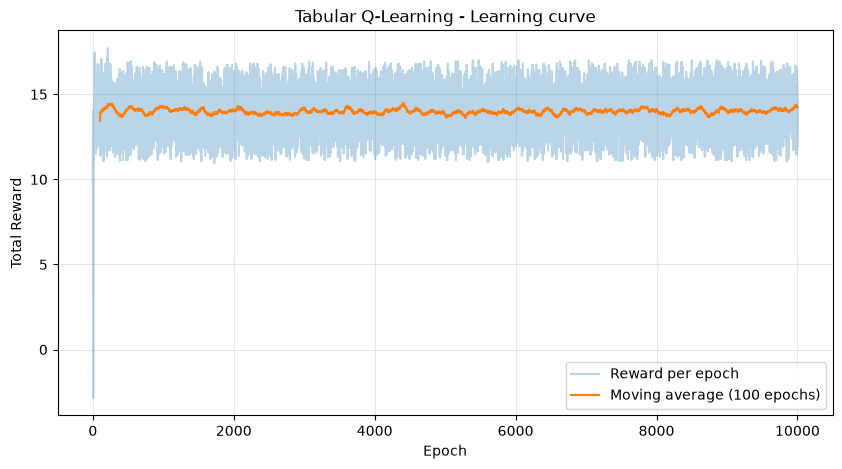

In [8]:
rewards_arr = np.array(rewards)
window = 100

# Moving average to smooth the noise from epsilon-greedy exploration
moving_avg = np.convolve(rewards_arr, np.ones(window) / window, mode = 'valid')

plt.figure(figsize = (10, 5))
plt.plot(rewards_arr, alpha = 0.3, label = "Reward per epoch")
plt.plot(range(window - 1, len(rewards_arr)), moving_avg, label = f"Moving average ({window} epochs)")
plt.xlabel("Epoch")
plt.ylabel("Total Reward")
plt.title("Tabular Q-Learning - Learning curve")
plt.legend()
plt.grid(alpha = 0.3)
plt.show()